In [19]:
import pandas as pd
import numpy as np
from warnings import filterwarnings
filterwarnings('ignore',category=UserWarning,module='matplotlib')
import seaborn as sns
import matplotlib.pyplot as plt

import mplcyberpunk
plt.style.use('cyberpunk')

In [3]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [11]:
df.tail()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [7]:
df.isna().mean() * 100

Student_ID                    0.0
Major_Category                0.0
Year_of_Study                 0.0
Pre_Semester_GPA              0.0
Weekly_GenAI_Hours            0.0
Primary_Use_Case              0.0
Prompt_Engineering_Skill      0.0
Tool_Diversity                0.0
Paid_Subscription             0.0
Traditional_Study_Hours       0.0
Perceived_AI_Dependency       0.0
Institutional_Policy          0.0
Anxiety_Level_During_Exams    0.0
Post_Semester_GPA             0.0
Skill_Retention_Score         0.0
Burnout_Risk_Level            0.0
dtype: float64

In [8]:
df.shape

(50000, 16)

In [9]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

In [10]:
df.columns = df.columns.str.lower()

In [14]:
df.sample(4)

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
26908,Arts,Freshman,3.628,10.59,Copywriting/Drafting,Intermediate,4,True,6.51,4,Allowed_With_Citation,6,3.674,74.76,Medium
34304,Arts,Junior,3.310,0.32,Ideation,Intermediate,3,True,13.80,2,Actively_Encouraged,1,3.348,69.47,Low
19336,Business,Freshman,3.416,5.45,Direct_Answer_Generation,Beginner,1,False,23.30,4,Allowed_With_Citation,2,3.641,80.13,Medium
46080,Arts,Senior,3.480,1.55,Copywriting/Drafting,Intermediate,1,True,8.69,1,Allowed_With_Citation,2,3.733,93.37,Low


In [13]:
df.drop(columns='student_id',inplace=True)

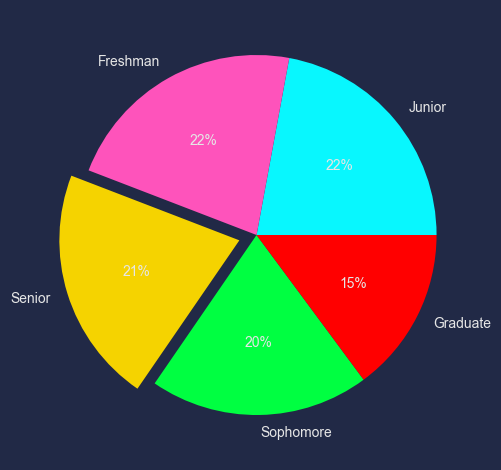

In [22]:
plt.pie(df['year_of_study'].value_counts(),
            labels=df['year_of_study'].value_counts().index,
            autopct='%1.f%%',explode=[0,0,0.1,0,0])


plt.tight_layout()

In [23]:
df.sample(4)

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
1224,Humanities,Freshman,2.897,0.77,Direct_Answer_Generation,Beginner,2,False,14.64,2,Allowed_With_Citation,6,2.948,87.65,Low
44452,Business,Sophomore,2.725,8.99,Debugging/Troubleshooting,Intermediate,2,False,10.84,5,Allowed_With_Citation,6,2.551,60.91,Low
21208,STEM,Sophomore,3.388,36.37,Debugging/Troubleshooting,Advanced,3,False,8.25,8,Strict_Ban,8,3.675,65.81,High
6119,Business,Junior,3.161,9.85,Direct_Answer_Generation,Beginner,2,False,7.41,2,Allowed_With_Citation,4,3.364,89.06,Medium


In [26]:
q1 = df['traditional_study_hours'].quantile(0.25)
q3 = df['traditional_study_hours'].quantile(0.75)

iqr = q3 - q1 

print(q1,q3,iqr)

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
print(f'{lower_limit=}')
print(f'{upper_limit=}')

7.56 14.71 7.150000000000001
lower_limit=np.float64(-3.165000000000002)
upper_limit=np.float64(25.435000000000002)


In [27]:
df[(df['traditional_study_hours'] < lower_limit) & (df['traditional_study_hours'] > upper_limit)]

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level


C:\Windows\Temp\ipykernel_18716\3400849650.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(df['traditional_study_hours'],palette='Set2')


<Axes: ylabel='traditional_study_hours'>

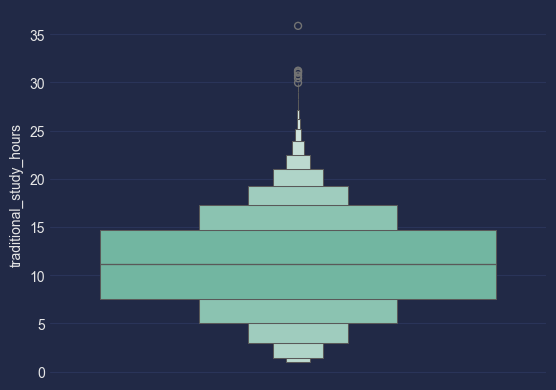

In [33]:
sns.boxenplot(df['traditional_study_hours'],palette='Set2')

C:\Windows\Temp\ipykernel_18716\4260951265.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df['traditional_study_hours'],palette='magma')


<Axes: ylabel='traditional_study_hours'>

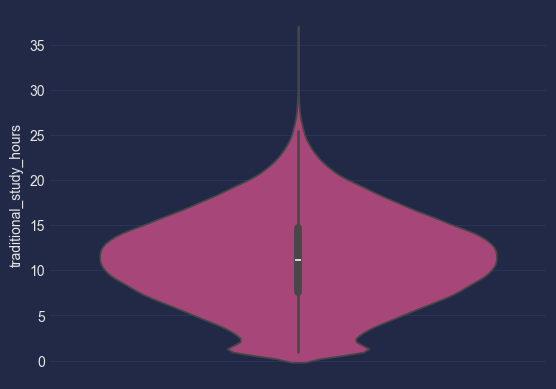

In [35]:
sns.violinplot(df['traditional_study_hours'],palette='magma')

In [36]:
df.sample(4)

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
14614,Business,Senior,3.258,2.80,Summarizing_Reading,Beginner,2,False,13.26,4,Allowed_With_Citation,7,3.808,81.04,Low
27041,STEM,Senior,2.428,12.77,Debugging/Troubleshooting,Intermediate,5,True,15.40,4,Strict_Ban,8,2.605,100.00,Medium
40744,Humanities,Junior,3.744,5.30,Copywriting/Drafting,Beginner,3,False,6.28,4,Strict_Ban,5,3.861,86.51,Low
8634,STEM,Sophomore,2.774,5.60,Debugging/Troubleshooting,Beginner,2,False,17.42,4,Allowed_With_Citation,1,3.459,63.78,Low


In [41]:
df.major_category.value_counts()

major_category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [42]:
df['year_of_study'].value_counts()

year_of_study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

In [44]:
df.groupby('major_category')['year_of_study'].value_counts().reset_index()

,major_category,year_of_study,count
0,Arts,Junior,1324
1,Arts,Senior,1301
2,Arts,Freshman,1282
3,Arts,Sophomore,1182
4,Arts,Graduate,844
5,Business,Junior,2845
6,Business,Freshman,2831
7,Business,Senior,2550
8,Business,Sophomore,2467
9,Business,Graduate,1845


In [45]:
df.sample(4)

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
40243,Medical,Senior,3.972,2.05,Summarizing_Reading,Beginner,2,False,13.26,3,Actively_Encouraged,3,4.000,75.57,Low
16289,STEM,Junior,2.854,5.99,Debugging/Troubleshooting,Intermediate,2,False,16.80,4,Allowed_With_Citation,3,3.122,64.90,High
17921,Medical,Freshman,2.811,12.46,Summarizing_Reading,Intermediate,1,True,9.94,4,Actively_Encouraged,9,2.711,73.24,Medium
45119,Business,Graduate,3.136,2.62,Ideation,Beginner,2,True,16.37,3,Actively_Encouraged,1,3.431,68.05,High


<Axes: ylabel='pre_semester_gpa'>

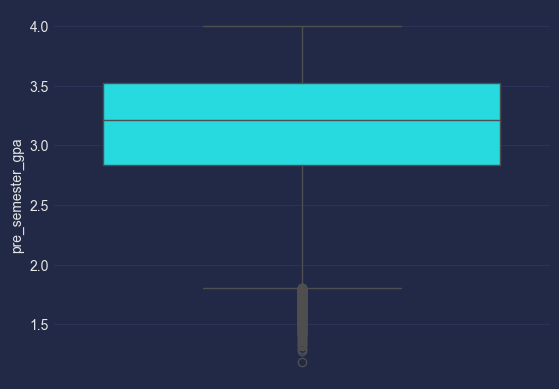

In [77]:
sns.boxplot(df['pre_semester_gpa'])

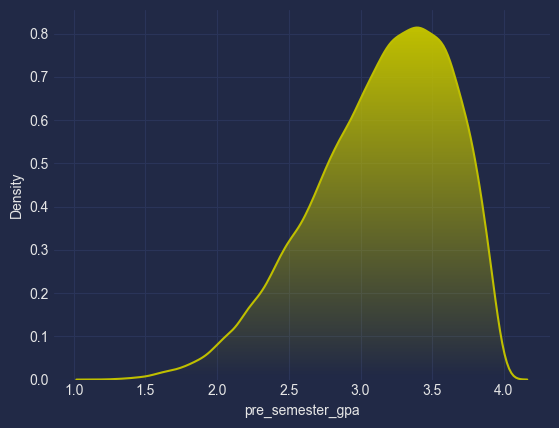

In [71]:
sns.kdeplot(df['pre_semester_gpa'],color='y')
# mplcyberpunk.add_glow_effects()
mplcyberpunk.add_gradient_fill()

In [51]:
df['pre_semester_gpa'].skew()

np.float64(-0.602042795770214)

<Axes: xlabel='pre_semester_gpa', ylabel='weekly_genai_hours'>

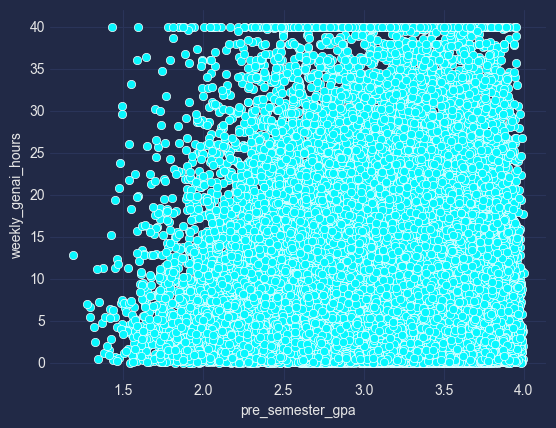

In [53]:
sns.scatterplot(x=df['pre_semester_gpa'],y=df['weekly_genai_hours'])

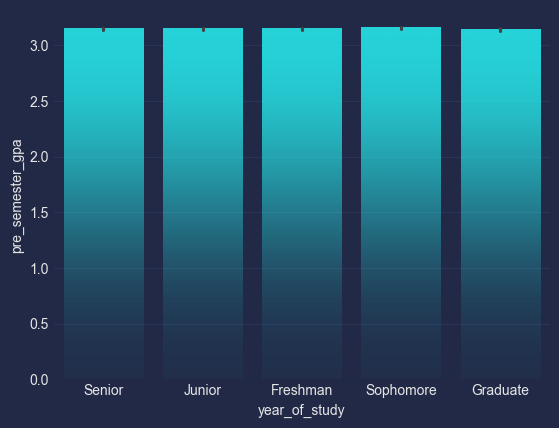

In [65]:
bar = sns.barplot(x=df['year_of_study'],y=df['pre_semester_gpa'])
mplcyberpunk.add_bar_gradient(bars=bar.containers[0])

In [72]:
df.sample(4)

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
6168,STEM,Senior,3.603,25.51,Debugging/Troubleshooting,Intermediate,3,True,11.06,7,Allowed_With_Citation,2,4.000,63.67,High
25921,Medical,Sophomore,2.925,5.39,Debugging/Troubleshooting,Intermediate,4,False,10.62,4,Actively_Encouraged,1,2.992,53.66,Medium
37871,Humanities,Sophomore,2.627,0.13,Direct_Answer_Generation,Beginner,1,True,11.70,3,Actively_Encouraged,2,2.630,63.85,High
40337,STEM,Senior,2.550,6.05,Summarizing_Reading,Intermediate,4,True,11.34,3,Allowed_With_Citation,2,2.665,79.88,Medium


In [73]:
df.weekly_genai_hours.mean()

np.float64(8.4277522)